# Stereo template matching/block matching


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import data

plt.gray()

<Figure size 432x288 with 0 Axes>

Start by loading a set of corresponding left and right image. We also resize the images since the computations we expect to do can take a long time to process. Resizing is optional, but recommended atleast until you have verified your computer is capable of doing the computations within reasonable time.

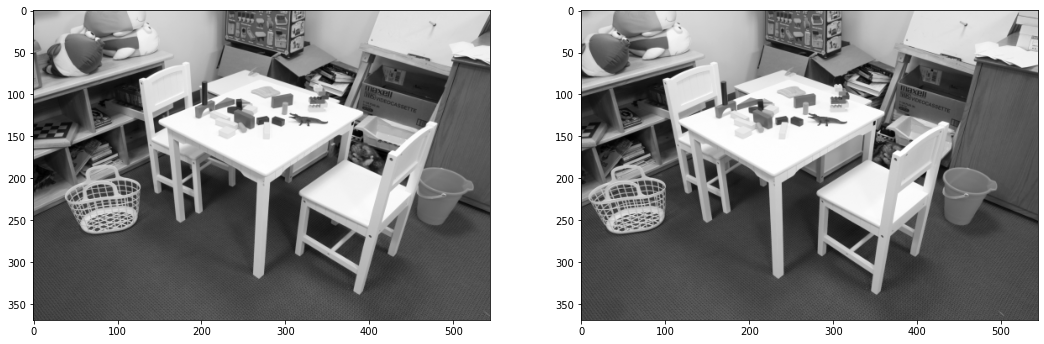

In [6]:
# load the images
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 3/"
img_left = cv2.imread(path + "playtable_left.png")
img_right = cv2.imread(path + "playtable_right.png")

# rescale images (can be left out)
# We downsample by a factor of 5 to speed up the block matching.
# Block matching is computationally expensive ($O(W \cdot H \cdot D \cdot B^2)$), so smaller images help significantly during testing.
img_size = (int(img_left.shape[1]/5), int(img_left.shape[0]/5))
img_left = cv2.resize(img_left, img_size, interpolation=cv2.INTER_AREA)
img_right = cv2.resize(img_right, img_size, interpolation=cv2.INTER_AREA)

# convert images to grayscale for template matching
# StereoBM only works on single-channel (grayscale) images.
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

f, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))
ax_left.imshow(gray_left)
ax_right.imshow(gray_right)

Next step is to create a disparity map based on the two stereo images. This is done using the same procedure as we did with exercise 1, except now we look for blocks of pixel from the left image in the right image, or vice versa.

## Exercise 2.1
You will have to play with the below parameters until you find a good solution that gives a representative 3D projection. Reflect/search on what those parameters actually mean and how they influence the outcome.

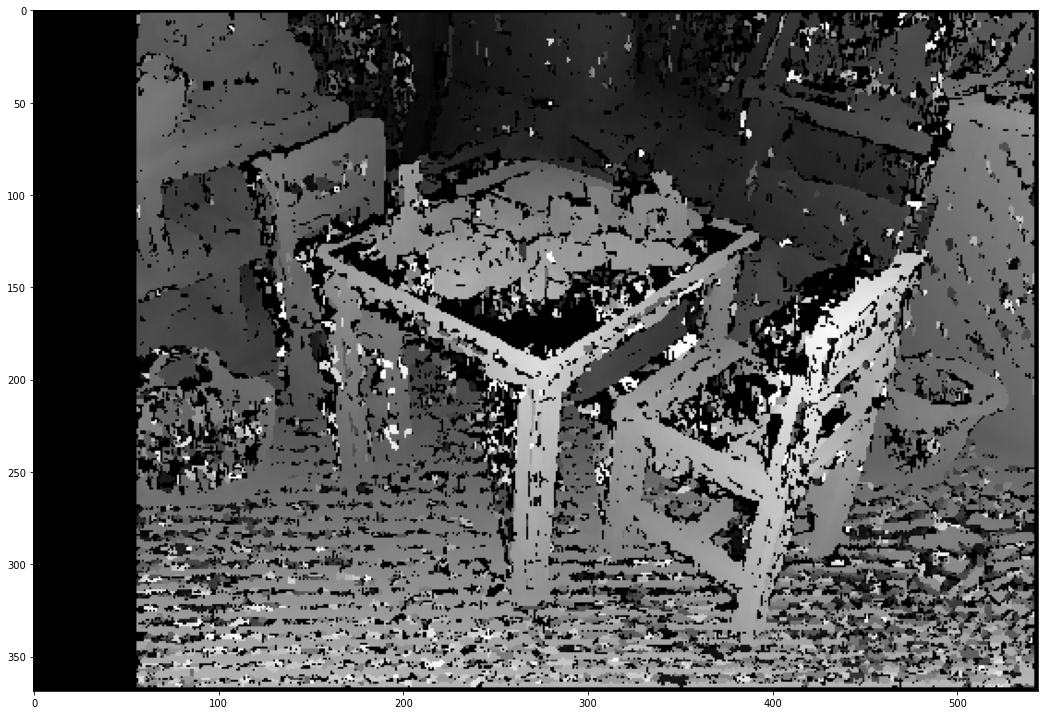

In [7]:
# Parameters for Stereo Block Matching
# Disparity is the distance between the same point in the left vs right image.
# Closer objects have high disparity, far objects have low disparity.

# minDisparity: Minimum possible disparity value. Ideally 0, but can be adjusted if the cameras are verged (tilted towards each other).
min_disp = 7

# numDisparities: The search range for the disparity.
# It MUST be divisible by 16.
# A higher number means we can detect objects closer to the camera, but it increases computation time.
num_disp = 3 * 16

# blockSize: The size of the sliding window (SAD window size).
# Must be an odd number (3, 5, 7...).
# Smaller block size => More detailed, but more noise.
# Larger block size => Smoother disparity map, less noise, but details are lost and "blobs" appear.
block_size = 5

# Create the StereoBM object
stereo = cv2.StereoBM_create(numDisparities = num_disp, blockSize = block_size)

# Fine-tuning parameters for noise filtering:
stereo.setMinDisparity(min_disp)

# disp12MaxDiff: Maximum allowed difference (in pixels) in the left-right disparity check.
# If the check fails, the pixel is invalidated. This removes "false positives".
stereo.setDisp12MaxDiff(200)

# uniquenessRatio: The margin (in %) by which the best matching block must win over the second best.
# E.g., if 5, the best match must be 5% better than the next best match. 
# Higher value => More pixels rejected (black holes), but higher confidence in the ones kept.
stereo.setUniquenessRatio(1)

# speckleWindowSize and speckleRange: Used to remove small "speckles" (noise blobs).
# speckleWindowSize: Max size of smooth disparity regions to consider "noise" and invalidate.
# speckleRange: Max disparity variation within a connected component.
stereo.setSpeckleRange(3)
stereo.setSpeckleWindowSize(3)

# Compute the disparity map
# The result is 16-bit signed integer. The values are scaled by 16 (fixed-point precision).
# To get the true disparity in pixels, we divide by 16.0.
disp = stereo.compute(gray_left, gray_right).astype(np.float32) / 16.0

plt.figure(figsize=(18,18))
plt.imshow(disp)

## Exercise 2.2
Once you have a disparity map without too much noise, you can use the below to export you disparity map to a .ply file that you can load and display in a 3D visualization software (e.g. [Meshlab](https://www.meshlab.net/#description)).

**Hint:** To open meshlab type `meshlab` in a terminal. 
To vizualize the point cloud, drag the generated `out.ply` into the meshlab scene or click `File` > `Import Mesh` and navigate to where our source-code is located and open `out.ply`. 

In [8]:
def export_pointcloud(disparity_map, colors):
    # PLY is a standard file format for 3D models.
    # We define a header that describes the data: x, y, z coordinates and r, g, b colors.
    ply_header = '''ply
    format ascii 1.0
    element vertex %(vert_num)d
    property float x
    property float y
    property float z
    property uchar red
    property uchar green
    property uchar blue
    end_header
    '''

    def write_ply(fn, verts, colors):
        verts = verts.reshape(-1, 3)
        colors = colors.reshape(-1, 3)
        verts = np.hstack([verts, colors])
        with open(fn, 'wb') as f:
            f.write((ply_header % dict(vert_num=len(verts))).encode('utf-8'))
            np.savetxt(f, verts, fmt='%f %f %f %d %d %d ')

    h, w = disparity_map.shape[:2]
    
    # Define the Reprojection Matrix Q.
    # Q maps pixel coordinates (x, y) and disparity (d) to 3D coordinates (X, Y, Z).
    # Z = f * B / d, where f is focal length and B is baseline (distance between cameras).
    f = .8 * w  # guess for focal length. If you 3D reconstruction looks skewed in the viewing direction, try adjusting this parameter.
    Q = np.float32([[1, 0, 0, -0.5 * w],
                    [0, -1, 0, 0.5 * h],  # turn points 180 deg around x-axis,
                    [0, 0, 0, -f],  # so that y-axis looks up
                    [0, 0, 1, 0]])
    
    # reprojectImageTo3D takes the disparity map and Q matrix and generates a 3D point cloud.
    points = cv2.reprojectImageTo3D(disparity_map, Q)
    
    # Filter out invalid points (where disparity is too low or invalid)
    mask = disparity_map > disparity_map.min()
    out_points = points[mask]
    out_colors = colors[mask]
    
    out_fn = 'out.ply'
    write_ply('out.ply', out_points, out_colors)
    print(f'{out_fn} saved')

export_pointcloud(disparity_map=disp, colors=img_left)

out.ply saved


## Exercise 2.3

Create a disparity map of the imageset `storage` and display it in meshlab.

out.ply saved


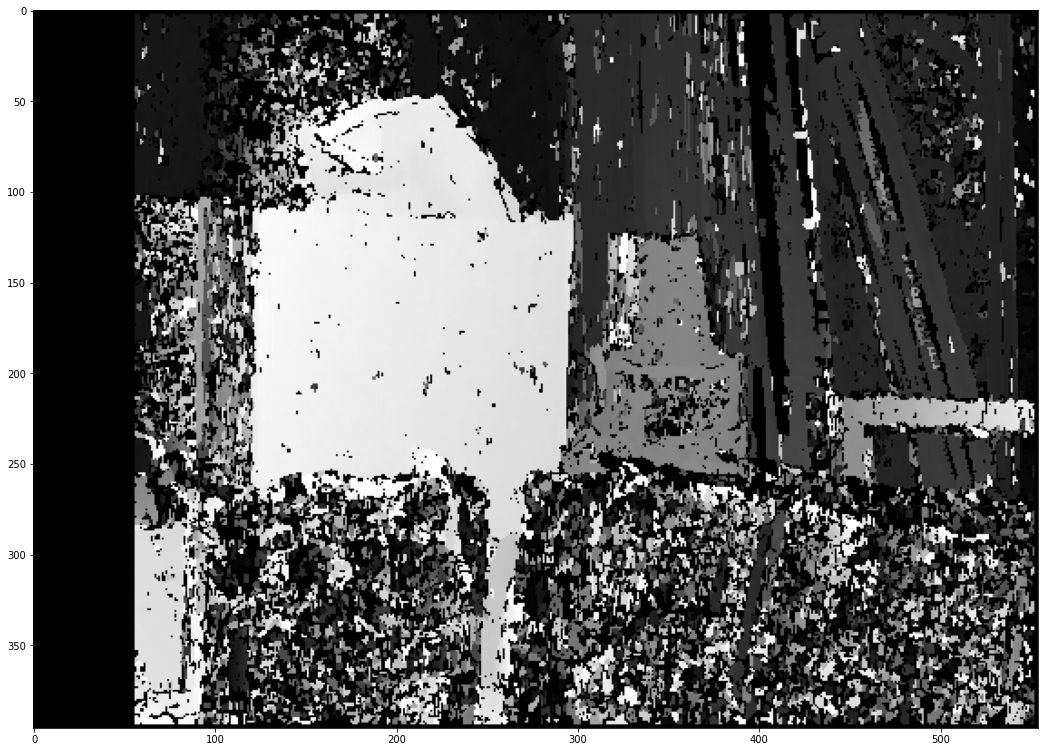

In [9]:
img2_left = cv2.imread(path + "storage_left.png")
img2_right = cv2.imread(path + "storage_right.png")

img2_size = (int(img2_left.shape[1]/5), int(img2_left.shape[0]/5))
img2_left = cv2.resize(img2_left, img2_size, interpolation=cv2.INTER_AREA)
img2_right = cv2.resize(img2_right, img2_size, interpolation=cv2.INTER_AREA)

gray2_left = cv2.cvtColor(img2_left, cv2.COLOR_BGR2GRAY)
gray2_right = cv2.cvtColor(img2_right, cv2.COLOR_BGR2GRAY)

# Tweaking parameters for the second image set.
# The 'storage' image might have different depth ranges or textures, so parameters often need adjustment.
min_disp = 7
num_disp = 3 * 16
block_size = 5

stereo2 = cv2.StereoBM_create(numDisparities = num_disp, blockSize = block_size)
stereo2.setMinDisparity(min_disp)
stereo2.setDisp12MaxDiff(200)
stereo2.setUniquenessRatio(1)
stereo2.setSpeckleRange(3)
stereo2.setSpeckleWindowSize(3)

disp2 = stereo2.compute(gray2_left, gray2_right).astype(np.float32) / 16.0

plt.figure(figsize=(18,18))
plt.imshow(disp2)

export_pointcloud(disparity_map=disp2, colors=img2_left)